# 69 — Does firm-specific economic materiality add value beyond polarity?

This notebook implements the researcher's explicit **model-only development-period waiver**. The human reliability gate remains unpassed; the Gemma annotations are therefore treated as an unvalidated measurement layer. The only return data admitted are exact LSEG adjusted-open returns whose entry and end sessions are both before 2026-01-01.

The primary question was frozen before return access: does signed `direction × materiality × novelty` add information beyond the existing continuous Gemma and FinBERT polarity scores? The notebook reports the full eight-test family, chronological OOS comparisons, a fixed h1/h5 sparse translation, reaction-magnitude diagnostics, costs and robustness. **No 2026 confirmation return is parsed or opened, and no result is presented as validated alpha.**

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "final_experiments").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.lseg_materiality import audit_completion_status, materiality_paths
from final_experiments.lib.lseg_materiality_returns import (
    CONFIRMATION_START,
    attach_forward_open_returns,
    benjamini_hochberg_qvalues,
    circular_block_mean_test,
    expanding_oos_predictions,
    expanding_oos_reaction_magnitude,
    fit_horizon_matched_materiality,
    fit_incremental_regression,
    fit_reaction_magnitude_regression,
    load_model_only_development_events,
    load_preconfirmation_lseg_prices,
    oos_daily_differences,
    run_sparse_strategy,
    summarize_sparse_strategy,
)
from final_experiments.lib.plots import (
    CATEGORICAL,
    INK,
    ORDINAL_BLUE,
    annotate_source,
    apply_house_style,
    zero_line,
)
from sentiment_benchmark.artifact_io import atomic_write_json, read_json, sha256_file

apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

MEASUREMENT_DIR = REPO_ROOT / "final_experiments/outputs/68_lseg_materiality_measurement_pilot"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/69_lseg_target_materiality_incremental_value"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PARENT_SPEC_PATH = REPO_ROOT / "final_experiments/frozen_specs/lseg_target_materiality_pilot_v1_20260812.json"
WAIVER_PATH = REPO_ROOT / "final_experiments/frozen_specs/lseg_target_materiality_model_only_development_waiver_20260812.json"
REACTION_SPEC_PATH = REPO_ROOT / "final_experiments/frozen_specs/lseg_target_materiality_reaction_magnitude_amendment_20260812.json"
COMPARATOR_SPEC_PATH = REPO_ROOT / "final_experiments/frozen_specs/lseg_target_materiality_h5_post_primary_comparator_amendment_20260812.json"
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_2024_2026.csv"

PARENT_SPEC = read_json(PARENT_SPEC_PATH)
WAIVER = read_json(WAIVER_PATH)
REACTION_SPEC = read_json(REACTION_SPEC_PATH)
COMPARATOR_SPEC = read_json(COMPARATOR_SPEC_PATH)
assert PARENT_SPEC["status"] == "frozen_before_return_access"
assert WAIVER["status"] == "frozen_before_model_only_development_return_access"
assert REACTION_SPEC["status"] == "frozen_after_directional_primary_before_reaction_magnitude_tests"
assert COMPARATOR_SPEC["status"] == "frozen_after_strategy_summaries_before_paired_comparator_inference"

SEED = 20_260_812
BLOCK_LENGTH = 5
BOOTSTRAP_REPLICATIONS = 9_999
PRIMARY_SIGNAL = "signed_materiality_novelty"
SIGNALS = (
    "direction_only",
    "signed_materiality",
    PRIMARY_SIGNAL,
    "score_gemma",
    "score_finbert",
    "combined_polarity",
)
SIGNAL_LABELS = {
    "direction_only": "New direction only",
    "signed_materiality": "Direction × materiality",
    PRIMARY_SIGNAL: "Direction × materiality × novelty",
    "score_gemma": "Existing Gemma polarity",
    "score_finbert": "Existing FinBERT polarity",
    "combined_polarity": "Combined existing polarity",
}

print("model-only development waiver:", True)
print("human measurement gate passed:", False)
print("confirmation start:", CONFIRMATION_START.date())

model-only development waiver: True
human measurement gate passed: False
confirmation start: 2026-01-01


## Fail-closed development population

The sample and score files are hash-bound to the waiver. Events are restricted to pre-2026 entry sessions before the price join. The price export's complete-file hash is verified, but numeric price fields are parsed only for dates before 2026-01-01. Every forward-return end date is checked again after construction.

In [2]:
paths = materiality_paths(MEASUREMENT_DIR)
human_status = audit_completion_status(output_root=MEASUREMENT_DIR)
assert human_status["status"] != "complete"

events = load_model_only_development_events(
    paths.sample_events,
    paths.model_scores,
    sample_sha256=WAIVER["immutable_inputs"]["sample_events"]["sha256"],
    score_sha256=WAIVER["immutable_inputs"]["model_scores"]["sha256"],
    expected_development_rows=WAIVER["development_population"]["body_available_model_scored_rows"],
)
prices, price_audit = load_preconfirmation_lseg_prices(
    PRICE_PATH,
    expected_sha256=WAIVER["immutable_inputs"]["price_export"]["sha256"],
)
panel, wide_prices = attach_forward_open_returns(events, prices)

return_columns = ["ret_open_h1", "ret_open_h5", "ret_open_h20"]
end_columns = ["return_end_h1", "return_end_h5", "return_end_h20"]
assert panel["entry_session"].max() < CONFIRMATION_START
assert max(panel[column].dropna().max() for column in end_columns) < CONFIRMATION_START
assert price_audit["numeric_confirmation_prices_parsed"] == 0
assert price_audit["confirmation_returns_materialised"] == 0

support = pd.DataFrame(
    [
        {
            "measurement_status": "model_only_unvalidated",
            "development_events": len(panel),
            "event_sessions": panel["entry_session"].nunique(),
            "companies": panel["symbol"].nunique(),
            "first_entry": panel["entry_session"].min().date().isoformat(),
            "last_entry": panel["entry_session"].max().date().isoformat(),
            "h1_returns": panel["ret_open_h1"].notna().sum(),
            "h5_returns": panel["ret_open_h5"].notna().sum(),
            "h20_returns": panel["ret_open_h20"].notna().sum(),
            "numeric_2026_prices_parsed": 0,
            "confirmation_returns_opened": 0,
        }
    ]
)
display(support.T)

,0
measurement_status,model_only_unvalidated
development_events,1200
event_sessions,455
companies,33
first_entry,2024-01-02
last_entry,2025-12-31
h1_returns,1198
h5_returns,1193
h20_returns,1169
numeric_2026_prices_parsed,0


## Frozen primary family

For h1 and h5, the nested regression adds the signed materiality-novelty signal to both existing polarity scores and company fixed effects; covariance is clustered by entry session. Three chronological expanding folds compare polarity-only and expanded prediction without using future targets. The strategy selects one strictly positive and one strictly negative event per eligible day, uses fixed equal legs, holds h1 or five overlapping h5 tranches, includes cash days and charges drift-aware turnover at 10 bps per side. Benjamini–Hochberg correction is applied once across all eight tests.

In [3]:
incremental_regressions = pd.DataFrame(
    [fit_incremental_regression(panel, horizon=horizon, signal_col=PRIMARY_SIGNAL) for horizon in (1, 5)]
)

oos_rows = []
oos_daily = {}
for horizon in (1, 5):
    predictions = expanding_oos_predictions(panel, horizon=horizon, signal_col=PRIMARY_SIGNAL)
    loss_daily, ic_daily = oos_daily_differences(predictions, horizon=horizon)
    oos_daily[(horizon, "loss")] = loss_daily
    oos_daily[(horizon, "ic")] = ic_daily
    loss_test = circular_block_mean_test(
        loss_daily["loss_improvement"],
        block_length=BLOCK_LENGTH,
        replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + 100 + horizon,
        alternative="greater",
    )
    ic_test = circular_block_mean_test(
        ic_daily["ic_improvement"],
        block_length=BLOCK_LENGTH,
        replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + 200 + horizon,
        alternative="greater",
    )
    oos_rows.extend(
        [
            {
                "horizon": horizon,
                "metric": "squared_loss_improvement",
                "effect": loss_test["mean"],
                "effect_percent_of_base_loss": 100.0 * loss_test["mean"] / loss_daily["loss_base"].mean(),
                "ci_low": loss_test["ci_low"],
                "ci_high": loss_test["ci_high"],
                "p_one_sided": loss_test["p"],
                "n_test_dates": loss_test["n"],
            },
            {
                "horizon": horizon,
                "metric": "daily_rank_ic_improvement",
                "effect": ic_test["mean"],
                "effect_percent_of_base_loss": np.nan,
                "ci_low": ic_test["ci_low"],
                "ci_high": ic_test["ci_high"],
                "p_one_sided": ic_test["p"],
                "n_test_dates": ic_test["n"],
            },
        ]
    )
oos_summary = pd.DataFrame(oos_rows)

strategy_rows = []
strategy_daily = {}
formation_counts = {}
for signal in SIGNALS:
    for horizon in (1, 5):
        for cost in (0, 10, 25, 50):
            daily, formations = run_sparse_strategy(
                panel,
                wide_prices,
                signal_col=signal,
                horizon=horizon,
                cost_bps_per_side=cost,
            )
            summary = summarize_sparse_strategy(daily, cost_bps_per_side=cost)
            strategy_rows.append(
                {
                    "signal": signal,
                    "signal_label": SIGNAL_LABELS[signal],
                    "horizon": horizon,
                    "formation_sessions": len(formations),
                    **summary,
                }
            )
            if cost == 10:
                strategy_daily[(signal, horizon)] = daily
                formation_counts[(signal, horizon)] = len(formations)
strategy_summary = pd.DataFrame(strategy_rows)

strategy_tests = {}
for horizon in (1, 5):
    daily = strategy_daily[(PRIMARY_SIGNAL, horizon)]
    strategy_tests[horizon] = circular_block_mean_test(
        daily["net_return"],
        block_length=BLOCK_LENGTH,
        replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + 300 + horizon,
        alternative="greater",
    )

primary_rows = []
for row in incremental_regressions.to_dict("records"):
    primary_rows.append(
        {
            "test": f"h{row['horizon']}_incremental_coefficient",
            "component": "date_clustered_regression",
            "horizon": row["horizon"],
            "effect": row["beta_bps_per_signal_sd"],
            "unit": "bps per signal SD",
            "expected_positive": row["expected_direction_positive"],
            "p_raw": row["p_two_sided"],
        }
    )
for row in oos_summary.to_dict("records"):
    primary_rows.append(
        {
            "test": f"h{row['horizon']}_oos_{row['metric']}",
            "component": "chronological_oos",
            "horizon": row["horizon"],
            "effect": row["effect"],
            "unit": "squared-return improvement" if row["metric"].startswith("squared") else "Spearman IC improvement",
            "expected_positive": row["effect"] > 0,
            "p_raw": row["p_one_sided"],
        }
    )
for horizon in (1, 5):
    test = strategy_tests[horizon]
    primary_rows.append(
        {
            "test": f"h{horizon}_strategy_net_mean_vs_cash_10bps",
            "component": "fixed_sparse_strategy",
            "horizon": horizon,
            "effect": test["mean"] * 10_000.0,
            "unit": "net bps per session",
            "expected_positive": test["mean"] > 0,
            "p_raw": test["p"],
        }
    )
primary_family = pd.DataFrame(primary_rows)
primary_family["bh_q"] = benjamini_hochberg_qvalues(primary_family["p_raw"])
primary_family["reject_q05"] = primary_family["bh_q"].lt(0.05) & primary_family["expected_positive"]

display(incremental_regressions[[
    "horizon", "n_events", "beta_bps_per_signal_sd", "ci_low_bps", "ci_high_bps", "p_two_sided", "delta_r2"
]])
display(oos_summary)
display(primary_family)
assert len(primary_family) == 8
assert not primary_family["reject_q05"].any()

,horizon,n_events,beta_bps_per_signal_sd,ci_low_bps,ci_high_bps,p_two_sided,delta_r2
0,1,1198,3.421039,-16.523492,23.365570,0.736206,0.000146
1,5,1193,12.821536,-22.165875,47.808947,0.471783,0.000482


,horizon,metric,effect,effect_percent_of_base_loss,ci_low,ci_high,p_one_sided,n_test_dates
0,1,squared_loss_improvement,0.000000,0.032416,-0.000003,0.000004,0.413600,342
1,1,daily_rank_ic_improvement,-0.004497,NaN,-0.029105,0.017813,0.658900,162
2,5,squared_loss_improvement,-0.000000,-0.013490,-0.000013,0.000013,0.499800,332
3,5,daily_rank_ic_improvement,-0.007823,NaN,-0.038524,0.021770,0.698000,161


,test,component,horizon,effect,unit,expected_positive,p_raw,bh_q,reject_q05
0,h1_incremental_coefficient,date_clustered_regression,1,3.421039,bps per signal SD,True,0.736206,0.841378,False
1,h5_incremental_coefficient,date_clustered_regression,5,12.821536,bps per signal SD,True,0.471783,0.841378,False
2,h1_oos_squared_loss_improvement,chronological_oos,1,0.000000,squared-return improvement,True,0.413600,0.841378,False
3,h1_oos_daily_rank_ic_improvement,chronological_oos,1,-0.004497,Spearman IC improvement,False,0.658900,0.841378,False
4,h5_oos_squared_loss_improvement,chronological_oos,5,-0.000000,squared-return improvement,False,0.499800,0.841378,False
5,h5_oos_daily_rank_ic_improvement,chronological_oos,5,-0.007823,Spearman IC improvement,False,0.698000,0.841378,False
6,h1_strategy_net_mean_vs_cash_10bps,fixed_sparse_strategy,1,-5.599413,net bps per session,False,0.980600,0.980600,False
7,h5_strategy_net_mean_vs_cash_10bps,fixed_sparse_strategy,5,0.407957,net bps per session,True,0.364100,0.841378,False


### Primary result

The signed materiality-novelty coefficient is positive at h1 and h5, but both confidence intervals comfortably include zero and the incremental R² is negligible. The expanded model improves neither chronological squared loss nor daily rank IC. The h1 trading translation is adverse. The h5 translation is descriptively positive and clears 10 bps on point-estimate break-even, but its cash comparison remains uncertain and no primary test survives the eight-test family.

findfont: Failed to find font weight medium, now using 400.


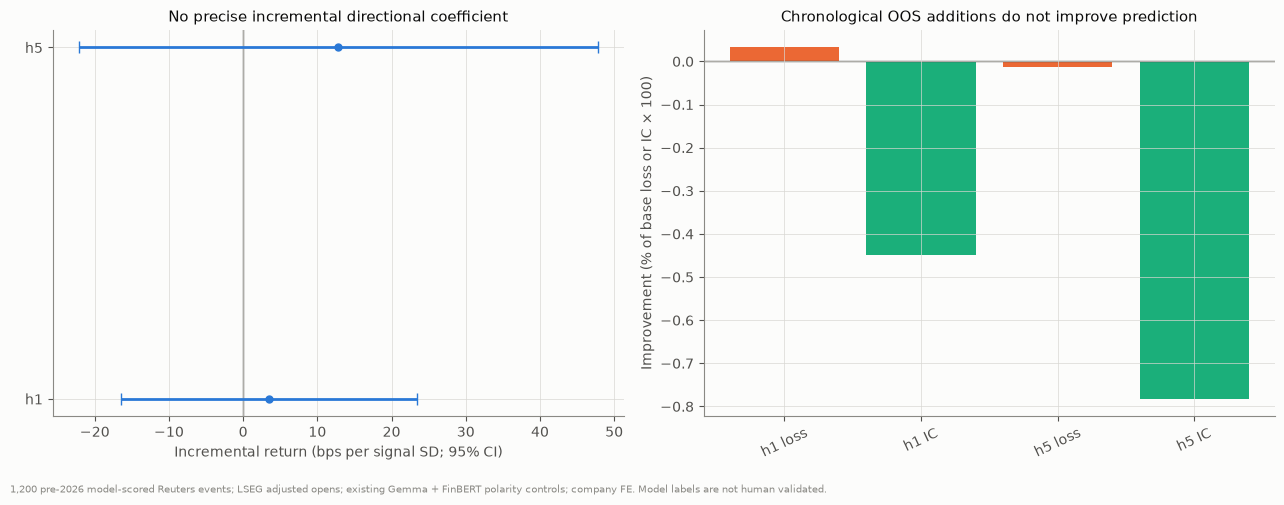

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

forest = incremental_regressions.sort_values("horizon")
y = np.arange(len(forest))
axes[0].errorbar(
    forest["beta_bps_per_signal_sd"],
    y,
    xerr=np.vstack([
        forest["beta_bps_per_signal_sd"] - forest["ci_low_bps"],
        forest["ci_high_bps"] - forest["beta_bps_per_signal_sd"],
    ]),
    fmt="o",
    color=CATEGORICAL[0],
    capsize=4,
)
zero_line(axes[0], axis="x")
axes[0].set_yticks(y, [f"h{value}" for value in forest["horizon"]])
axes[0].set_xlabel("Incremental return (bps per signal SD; 95% CI)")
axes[0].set_title("No precise incremental directional coefficient")

oos_plot = oos_summary.copy()
oos_plot["label"] = [f"h{h} loss" if metric.startswith("squared") else f"h{h} IC" for h, metric in zip(oos_plot["horizon"], oos_plot["metric"], strict=True)]
loss_scale = oos_plot["metric"].eq("squared_loss_improvement")
oos_plot.loc[loss_scale, "plot_effect"] = oos_plot.loc[loss_scale, "effect_percent_of_base_loss"]
oos_plot.loc[~loss_scale, "plot_effect"] = oos_plot.loc[~loss_scale, "effect"] * 100.0
colors = [CATEGORICAL[1] if value else CATEGORICAL[2] for value in loss_scale]
axes[1].bar(oos_plot["label"], oos_plot["plot_effect"], color=colors)
zero_line(axes[1])
axes[1].set_ylabel("Improvement (% of base loss or IC × 100)")
axes[1].set_title("Chronological OOS additions do not improve prediction")
axes[1].tick_params(axis="x", rotation=25)

fig.tight_layout()
annotate_source(
    fig,
    "1,200 pre-2026 model-scored Reuters events; LSEG adjusted opens; existing Gemma + FinBERT polarity controls; company FE. Model labels are not human validated.",
)
fig.savefig(FIGURE_DIR / "directional_incremental_and_oos.png", dpi=180, bbox_inches="tight")
plt.show()

## Strategy translation and post-primary comparison

The h5 result below is useful but must be read in the correct order. The candidate's positive development summary was visible before the paired comparator family was frozen, so those five comparisons are explicitly outcome-selected post-primary diagnostics. They can show relative implementation behaviour; they cannot establish alpha.

In [5]:
candidate_h5 = strategy_daily[(PRIMARY_SIGNAL, 5)].set_index("session_date")["net_return"]
comparison_rows = []
for offset, comparator in enumerate(
    ("direction_only", "signed_materiality", "score_gemma", "score_finbert", "combined_polarity"),
    start=1,
):
    comparator_path = strategy_daily[(comparator, 5)].set_index("session_date")["net_return"]
    paired = candidate_h5 - comparator_path
    test = circular_block_mean_test(
        paired,
        block_length=BLOCK_LENGTH,
        replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + 400 + offset,
        alternative="greater",
    )
    comparison_rows.append(
        {
            "candidate": PRIMARY_SIGNAL,
            "comparator": comparator,
            "comparator_label": SIGNAL_LABELS[comparator],
            "difference_bps_session": test["mean"] * 10_000.0,
            "ci_low_bps": test["ci_low"] * 10_000.0,
            "ci_high_bps": test["ci_high"] * 10_000.0,
            "p_one_sided": test["p"],
        }
    )
post_primary_comparisons = pd.DataFrame(comparison_rows)
post_primary_comparisons["bh_q"] = benjamini_hochberg_qvalues(post_primary_comparisons["p_one_sided"])
post_primary_comparisons["reject_q05"] = post_primary_comparisons["bh_q"].lt(0.05)

cost10_h5 = strategy_summary.loc[
    strategy_summary["horizon"].eq(5) & strategy_summary["cost_bps_per_side"].eq(10),
    [
        "signal", "signal_label", "formation_sessions", "gross_sharpe", "net_sharpe",
        "total_return_net", "breakeven_bps_per_side", "mean_turnover",
    ],
].copy()
display(cost10_h5)
display(post_primary_comparisons)

candidate_summary = cost10_h5.set_index("signal").loc[PRIMARY_SIGNAL]
assert candidate_summary["gross_sharpe"] > 0
assert candidate_summary["breakeven_bps_per_side"] > 10
assert primary_family.loc[primary_family["test"].eq("h5_strategy_net_mean_vs_cash_10bps"), "reject_q05"].eq(False).all()

,signal,signal_label,formation_sessions,gross_sharpe,net_sharpe,total_return_net,breakeven_bps_per_side,mean_turnover
5,direction_only,New direction only,153,0.580700,-0.024209,-0.005029,9.599697,0.061275
13,signed_materiality,Direction × materiality,153,0.419592,-0.170644,-0.020409,7.109172,0.061699
21,signed_materiality_novelty,Direction × materiality × novelty,112,0.741300,0.229787,0.018627,14.483909,0.045491
29,score_gemma,Existing Gemma polarity,230,0.310415,-0.409980,-0.055561,4.306963,0.092858
37,score_finbert,Existing FinBERT polarity,248,-0.796932,-1.535948,-0.191275,-10.751216,0.099869
45,combined_polarity,Combined existing polarity,244,-0.192536,-0.889275,-0.122224,-2.755944,0.098073


,candidate,comparator,comparator_label,difference_bps_session,ci_low_bps,ci_high_bps,p_one_sided,bh_q,reject_q05
0,signed_materiality_novelty,direction_only,New direction only,0.457014,-1.484997,2.401679,0.317200,0.317200,False
1,signed_materiality_novelty,signed_materiality,Direction × materiality,0.764677,-1.158385,2.705731,0.218100,0.272625,False
2,signed_materiality_novelty,score_gemma,Existing Gemma polarity,1.465247,-1.568109,4.665298,0.185100,0.272625,False
3,signed_materiality_novelty,score_finbert,Existing FinBERT polarity,4.552781,1.172223,8.074255,0.006200,0.031000,True
4,signed_materiality_novelty,combined_polarity,Combined existing polarity,2.909987,-0.633893,6.536907,0.057700,0.144250,False


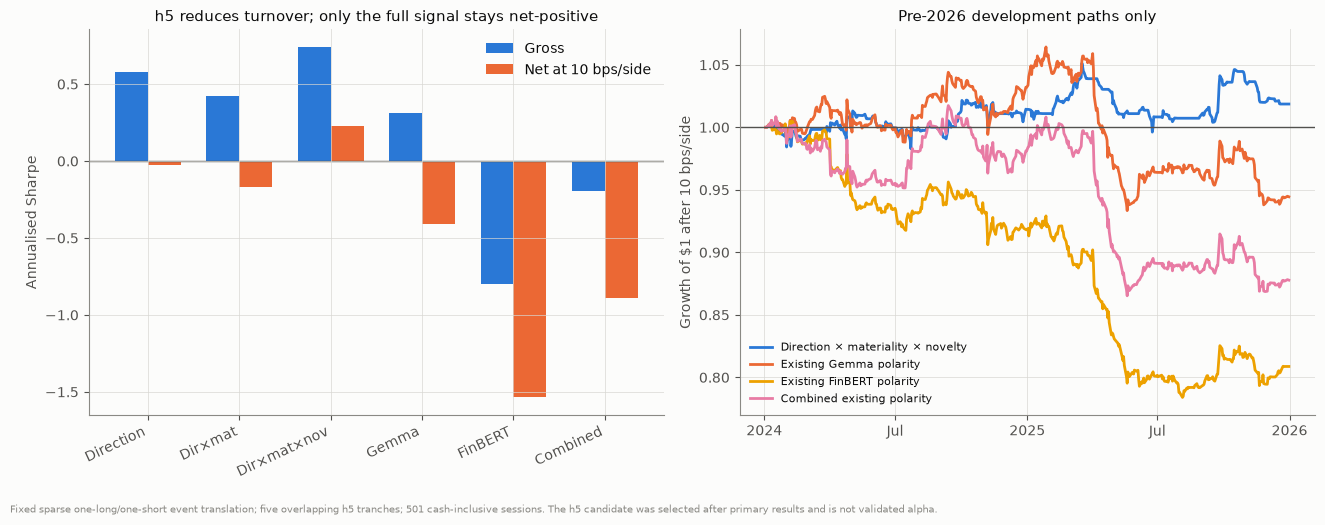

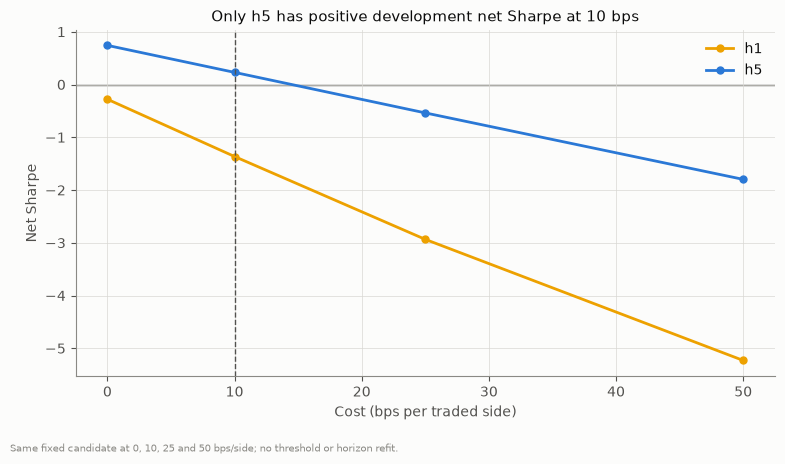

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0))

bar = cost10_h5.set_index("signal").loc[list(SIGNALS)]
x = np.arange(len(bar))
width = 0.36
axes[0].bar(x - width / 2, bar["gross_sharpe"], width, label="Gross", color=CATEGORICAL[0])
axes[0].bar(x + width / 2, bar["net_sharpe"], width, label="Net at 10 bps/side", color=CATEGORICAL[1])
zero_line(axes[0])
axes[0].set_xticks(x, ["Direction", "Dir×mat", "Dir×mat×nov", "Gemma", "FinBERT", "Combined"], rotation=25, ha="right")
axes[0].set_ylabel("Annualised Sharpe")
axes[0].set_title("h5 reduces turnover; only the full signal stays net-positive")
axes[0].legend(frameon=False)

path_signals = (PRIMARY_SIGNAL, "score_gemma", "score_finbert", "combined_polarity")
for signal, colour in zip(path_signals, (CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[3], CATEGORICAL[4]), strict=True):
    daily = strategy_daily[(signal, 5)]
    equity = (1.0 + daily["net_return"]).cumprod()
    axes[1].plot(daily["return_end_date"], equity, label=SIGNAL_LABELS[signal], color=colour)
axes[1].axhline(1.0, color=INK["reference"], lw=1.0)
locator = mdates.AutoDateLocator(minticks=5, maxticks=7)
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
axes[1].set_ylabel("Growth of $1 after 10 bps/side")
axes[1].set_title("Pre-2026 development paths only")
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
annotate_source(
    fig,
    "Fixed sparse one-long/one-short event translation; five overlapping h5 tranches; 501 cash-inclusive sessions. The h5 candidate was selected after primary results and is not validated alpha.",
)
fig.savefig(FIGURE_DIR / "h5_strategy_translation.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.4))
candidate_cost = strategy_summary.loc[strategy_summary["signal"].eq(PRIMARY_SIGNAL)]
for horizon, colour in ((1, CATEGORICAL[3]), (5, CATEGORICAL[0])):
    line = candidate_cost.loc[candidate_cost["horizon"].eq(horizon)].sort_values("cost_bps_per_side")
    ax.plot(line["cost_bps_per_side"], line["net_sharpe"], marker="o", color=colour, label=f"h{horizon}")
zero_line(ax)
ax.axvline(10, color=INK["reference"], ls="--", lw=1.0)
ax.set_xlabel("Cost (bps per traded side)")
ax.set_ylabel("Net Sharpe")
ax.set_title("Only h5 has positive development net Sharpe at 10 bps")
ax.legend(frameon=False)
fig.tight_layout()
annotate_source(fig, "Same fixed candidate at 0, 10, 25 and 50 bps/side; no threshold or horizon refit.")
fig.savefig(FIGURE_DIR / "candidate_cost_curve.png", dpi=180, bbox_inches="tight")
plt.show()

## Post-primary reaction-magnitude family

Economic materiality may be more naturally related to the *size* of a price reaction than its sign. This distinct family was frozen only after the directional primary family was known to be null, and before any absolute-return result was computed. It controls for absolute Gemma and FinBERT polarity strength, novelty and company fixed effects. It is an exploratory risk/attention test, not a trading-strategy rescue.

In [7]:
reaction_regressions = pd.DataFrame(
    [fit_reaction_magnitude_regression(panel, horizon=horizon) for horizon in (1, 5, 20)]
)
reaction_regressions["bh_q"] = benjamini_hochberg_qvalues(reaction_regressions["p_one_sided"])
reaction_regressions["reject_q05"] = reaction_regressions["bh_q"].lt(0.05) & reaction_regressions["expected_direction_positive"]

reaction_oos_rows = []
for horizon in (1, 5, 20):
    predictions = expanding_oos_reaction_magnitude(panel, horizon=horizon)
    daily = predictions.groupby("entry_session", as_index=False).agg(
        loss_improvement=("loss_improvement", "mean"),
        loss_base=("loss_base", "mean"),
        loss_expanded=("loss_expanded", "mean"),
        n_events=("audit_id", "size"),
    )
    test = circular_block_mean_test(
        daily["loss_improvement"],
        block_length=BLOCK_LENGTH,
        replications=BOOTSTRAP_REPLICATIONS,
        seed=SEED + 500 + horizon,
        alternative="greater",
    )
    reaction_oos_rows.append(
        {
            "horizon": horizon,
            "n_test_dates": test["n"],
            "loss_improvement": test["mean"],
            "improvement_percent_of_base_loss": 100.0 * test["mean"] / daily["loss_base"].mean(),
            "ci_low": test["ci_low"],
            "ci_high": test["ci_high"],
            "p_one_sided": test["p"],
        }
    )
reaction_oos = pd.DataFrame(reaction_oos_rows)
reaction_oos["bh_q"] = benjamini_hochberg_qvalues(reaction_oos["p_one_sided"])
reaction_oos["reject_q05"] = reaction_oos["bh_q"].lt(0.05) & reaction_oos["loss_improvement"].gt(0)

bucket_order = ["none", "low", "moderate", "high_or_very_high"]
bucket_frame = panel.copy()
bucket_frame["materiality_bucket"] = bucket_frame["materiality"].replace({"high": "high_or_very_high", "very_high": "high_or_very_high"})
bucket_rows = []
for horizon in (1, 5, 20):
    bucket_frame[f"absolute_return_h{horizon}"] = bucket_frame[f"ret_open_h{horizon}"].abs()
    grouped = bucket_frame.groupby("materiality_bucket", observed=True)[f"absolute_return_h{horizon}"]
    for bucket, values in grouped:
        values = values.dropna()
        bucket_rows.append(
            {
                "horizon": horizon,
                "materiality_bucket": bucket,
                "n_events": len(values),
                "mean_absolute_return_bps": values.mean() * 10_000.0,
                "median_absolute_return_bps": values.median() * 10_000.0,
            }
        )
reaction_buckets = pd.DataFrame(bucket_rows)

display(reaction_regressions[[
    "horizon", "beta_bps_per_materiality_sd", "ci_low_bps", "ci_high_bps", "p_one_sided", "bh_q", "r2"
]])
display(reaction_oos)
assert not reaction_regressions["reject_q05"].any()
assert not reaction_oos["reject_q05"].any()

,horizon,beta_bps_per_materiality_sd,ci_low_bps,ci_high_bps,p_one_sided,bh_q,r2
0,1,8.348591,-2.241180,18.938362,0.061004,0.183011,0.131500
1,5,10.286323,-9.500933,30.073579,0.153753,0.230630,0.140343
2,20,9.637202,-30.985257,50.259660,0.320627,0.320627,0.181348


,horizon,n_test_dates,loss_improvement,improvement_percent_of_base_loss,ci_low,ci_high,p_one_sided,bh_q,reject_q05
0,1,342,0.000001,0.479704,-0.000000,0.000003,0.082700,0.248100,False
1,5,332,0.000002,0.204371,-0.000005,0.000008,0.290500,0.435750,False
2,20,289,-0.000019,-0.472986,-0.000054,0.000013,0.873400,0.873400,False


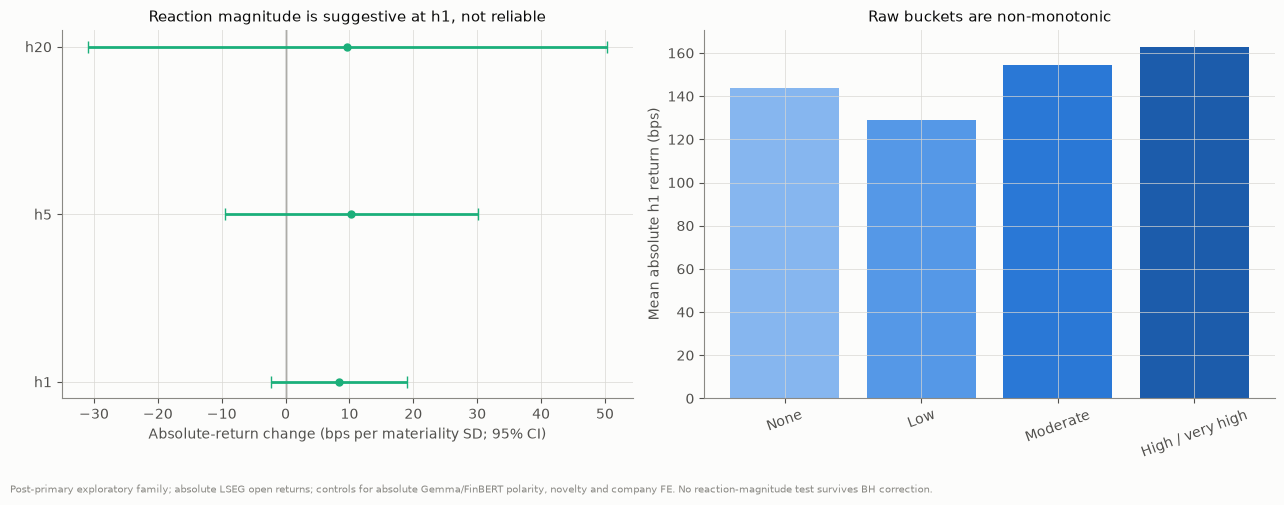

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

forest = reaction_regressions.sort_values("horizon")
y = np.arange(len(forest))
axes[0].errorbar(
    forest["beta_bps_per_materiality_sd"],
    y,
    xerr=np.vstack([
        forest["beta_bps_per_materiality_sd"] - forest["ci_low_bps"],
        forest["ci_high_bps"] - forest["beta_bps_per_materiality_sd"],
    ]),
    fmt="o",
    color=CATEGORICAL[2],
    capsize=4,
)
zero_line(axes[0], axis="x")
axes[0].set_yticks(y, [f"h{value}" for value in forest["horizon"]])
axes[0].set_xlabel("Absolute-return change (bps per materiality SD; 95% CI)")
axes[0].set_title("Reaction magnitude is suggestive at h1, not reliable")

h1_buckets = reaction_buckets.loc[reaction_buckets["horizon"].eq(1)].set_index("materiality_bucket").reindex(bucket_order)
axes[1].bar(
    ["None", "Low", "Moderate", "High / very high"],
    h1_buckets["mean_absolute_return_bps"],
    color=ORDINAL_BLUE[:4],
)
axes[1].set_ylabel("Mean absolute h1 return (bps)")
axes[1].set_title("Raw buckets are non-monotonic")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
annotate_source(
    fig,
    "Post-primary exploratory family; absolute LSEG open returns; controls for absolute Gemma/FinBERT polarity, novelty and company FE. No reaction-magnitude test survives BH correction.",
)
fig.savefig(FIGURE_DIR / "reaction_magnitude.png", dpi=180, bbox_inches="tight")
plt.show()

## Mechanism and stability diagnostics

These checks were predeclared as secondary or explicitly frozen post-primary. They describe whether any apparent effect has a coherent interpretation; they do not add promotion tests. The prompt's immediate, short and medium horizon labels are tested only against their matching h1, h5 and h20 returns. Year and leave-one-company-out results reveal temporal and name dependence.

In [9]:
ablation_rows = []
for signal in ("direction_only", "signed_materiality", PRIMARY_SIGNAL):
    for horizon in (1, 5, 20):
        ablation_rows.append(fit_incremental_regression(panel, horizon=horizon, signal_col=signal))
ablation_regressions = pd.DataFrame(ablation_rows)

horizon_matched = pd.DataFrame(
    [
        fit_horizon_matched_materiality(panel, horizon=1, horizon_label="immediate_1_session"),
        fit_horizon_matched_materiality(panel, horizon=5, horizon_label="short_2_5_sessions"),
        fit_horizon_matched_materiality(panel, horizon=20, horizon_label="medium_6_20_sessions"),
    ]
)
horizon_matched["bh_q"] = benjamini_hochberg_qvalues(horizon_matched["p_one_sided"])
horizon_matched["reject_q05"] = horizon_matched["bh_q"].lt(0.05) & horizon_matched["expected_direction_positive"]

temporal_rows = []
for year in (2024, 2025):
    year_panel = panel.loc[panel["entry_session"].dt.year.eq(year)]
    for horizon in (1, 5):
        row = fit_incremental_regression(year_panel, horizon=horizon, signal_col=PRIMARY_SIGNAL)
        temporal_rows.append({"family": "directional", "year": year, **row})
    for horizon in (1, 5, 20):
        row = fit_reaction_magnitude_regression(year_panel, horizon=horizon)
        temporal_rows.append({"family": "reaction_magnitude", "year": year, **row})
temporal_coefficients = pd.DataFrame(temporal_rows)

candidate_daily = strategy_daily[(PRIMARY_SIGNAL, 5)].copy()
strategy_year_rows = []
for year, year_daily in candidate_daily.groupby(candidate_daily["session_date"].dt.year):
    strategy_year_rows.append({"year": int(year), **summarize_sparse_strategy(year_daily, cost_bps_per_side=10)})
strategy_by_year = pd.DataFrame(strategy_year_rows)

loo_rows = []
for removed_symbol in sorted(panel["symbol"].unique()):
    kept = panel.loc[~panel["symbol"].eq(removed_symbol)]
    for horizon in (1, 5):
        row = fit_incremental_regression(kept, horizon=horizon, signal_col=PRIMARY_SIGNAL)
        loo_rows.append({"family": "directional", "removed_symbol": removed_symbol, **row})
    for horizon in (1, 5, 20):
        row = fit_reaction_magnitude_regression(kept, horizon=horizon)
        loo_rows.append({"family": "reaction_magnitude", "removed_symbol": removed_symbol, **row})
leave_one_company_out = pd.DataFrame(loo_rows)

loo_summary = leave_one_company_out.groupby(["family", "horizon"], as_index=False).agg(
    coefficient_min_bps=("beta_bps_per_signal_sd", "min"),
    coefficient_max_bps=("beta_bps_per_signal_sd", "max"),
    positive_replays=("expected_direction_positive", "sum"),
    replays=("removed_symbol", "size"),
)
# Reaction rows use a differently named coefficient.
reaction_loo = leave_one_company_out["family"].eq("reaction_magnitude")
loo_summary = leave_one_company_out.assign(
    common_beta=np.where(
        reaction_loo,
        leave_one_company_out.get("beta_bps_per_materiality_sd"),
        leave_one_company_out.get("beta_bps_per_signal_sd"),
    )
).groupby(["family", "horizon"], as_index=False).agg(
    coefficient_min_bps=("common_beta", "min"),
    coefficient_max_bps=("common_beta", "max"),
    positive_replays=("expected_direction_positive", "sum"),
    replays=("removed_symbol", "size"),
)

display(horizon_matched)
display(strategy_by_year[["year", "gross_sharpe", "net_sharpe", "total_return_net", "breakeven_bps_per_side"]])
display(loo_summary)
assert not horizon_matched["reject_q05"].any()

,horizon,valuation_horizon,n_events,n_sessions,status,beta_bps_per_materiality_sd,cluster_se_bps,p_one_sided,expected_direction_positive,bh_q,reject_q05
0,1,immediate_1_session,217,172,estimated,12.483057,21.007224,0.276573,True,0.414859,False
1,5,short_2_5_sessions,23,23,estimated,64.034743,103.133872,0.270526,True,0.414859,False
2,20,medium_6_20_sessions,328,238,estimated,-39.968351,63.811015,0.734158,False,0.734158,False


,year,gross_sharpe,net_sharpe,total_return_net,breakeven_bps_per_side
0,2024,0.848780,0.309712,0.014318,15.750612
1,2025,0.613366,0.129577,0.004248,12.664017


,family,horizon,coefficient_min_bps,coefficient_max_bps,positive_replays,replays
0,directional,1,-2.823789,8.891709,32,33
1,directional,5,-2.126976,20.810021,32,33
2,reaction_magnitude,1,4.941466,12.619087,33,33
3,reaction_magnitude,5,1.920876,13.734003,33,33
4,reaction_magnitude,20,2.479223,16.585799,33,33


## Dissertation interpretation

The model-only experiment supports a bounded, credible dissertation finding rather than a deployable strategy:

1. **Richer semantic annotation did not add robust directional return information beyond polarity.** Both incremental coefficients were small relative to their uncertainty; chronological OOS loss and IC were flat to worse; none of eight primary tests survived BH correction.
2. **Holding-period and event selection changed implementation economics.** The predeclared h5 novelty-weighted materiality translation achieved positive gross/net point estimates and a 14.5 bps/side break-even, unlike the polarity-only translations. However it did not distinguish itself from cash, and the favourable FinBERT comparison was selected post-primary.
3. **Materiality was not a reliable volatility/attention proxy either.** The h1 reaction-magnitude coefficient was positive and temporally same-signed, but it missed nominal significance, failed BH correction and did not produce reliable OOS loss improvement.
4. **The measurement limitation is central.** Human labels remain absent and Gemma marked evidence sufficient on every scored row. The thesis can therefore evaluate whether richer LLM constructs *appear economically useful under model-only labels*, while treating construct validity and untouched confirmation as future gates.

This is useful because it separates three claims that sentiment-trading work often conflates: richer labels can alter portfolio turnover, can outperform a weak polarity translation, and still fail to demonstrate independent or confirmed alpha.

In [10]:
# Persist aggregate, licence-safe evidence. No headline, body, row-level price or 2026 return is written.
tables = {
    "support.csv": support,
    "incremental_regressions.csv": incremental_regressions,
    "oos_summary.csv": oos_summary,
    "primary_family.csv": primary_family,
    "strategy_summary.csv": strategy_summary,
    "post_primary_h5_comparisons.csv": post_primary_comparisons,
    "reaction_magnitude_regressions.csv": reaction_regressions,
    "reaction_magnitude_oos.csv": reaction_oos,
    "reaction_magnitude_buckets.csv": reaction_buckets,
    "ablation_regressions.csv": ablation_regressions,
    "horizon_matched.csv": horizon_matched,
    "temporal_coefficients.csv": temporal_coefficients,
    "strategy_by_year.csv": strategy_by_year,
    "leave_one_company_out.csv": leave_one_company_out,
    "leave_one_company_out_summary.csv": loo_summary,
}
for filename, table in tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=False)

def json_records(frame: pd.DataFrame) -> list[dict[str, object]]:
    return json.loads(frame.to_json(orient="records", date_format="iso"))

candidate_record = strategy_summary.loc[
    strategy_summary["signal"].eq(PRIMARY_SIGNAL)
    & strategy_summary["horizon"].eq(5)
    & strategy_summary["cost_bps_per_side"].eq(10)
].iloc[0]
finbert_comparison = post_primary_comparisons.loc[
    post_primary_comparisons["comparator"].eq("score_finbert")
].iloc[0]

output_files = sorted(
    [path for path in OUTPUT_DIR.glob("*.csv")]
    + [path for path in FIGURE_DIR.glob("*.png")]
)
manifest = {
    "schema_version": 1,
    "status": "MODEL_ONLY_DEVELOPMENT_COMPLETE_CONFIRMATION_SEALED",
    "notebook": "69_lseg_target_materiality_incremental_value.ipynb",
    "git_commit_at_execution": subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True
    ).strip(),
    "measurement_status": "model_only_unvalidated",
    "human_reliability_gate_passed": False,
    "waiver_scope": "model-only exploratory pre-2026 return analysis only",
    "claim_boundary": "development evidence; not validated alpha",
    "frozen_specs": {
        str(path.relative_to(REPO_ROOT)): sha256_file(path)
        for path in (PARENT_SPEC_PATH, WAIVER_PATH, REACTION_SPEC_PATH, COMPARATOR_SPEC_PATH)
    },
    "inputs": {
        "sample_events_sha256": sha256_file(paths.sample_events),
        "model_scores_sha256": sha256_file(paths.model_scores),
        "price_export_sha256": sha256_file(PRICE_PATH),
    },
    "seal_audit": {
        **price_audit,
        "development_event_rows": int(len(panel)),
        "last_entry_session_opened": panel["entry_session"].max().date().isoformat(),
        "last_return_end_session_opened": max(panel[column].dropna().max() for column in end_columns).date().isoformat(),
        "numeric_confirmation_prices_parsed": 0,
        "confirmation_event_returns_opened": 0,
        "confirmation_strategy_sessions_opened": 0,
    },
    "primary_family": {
        "tests": 8,
        "bh_q": 0.05,
        "rejections": int(primary_family["reject_q05"].sum()),
        "results": json_records(primary_family),
    },
    "candidate_h5_development_summary": {
        "gross_sharpe": float(candidate_record["gross_sharpe"]),
        "net_sharpe_10bps": float(candidate_record["net_sharpe"]),
        "net_return_10bps": float(candidate_record["total_return_net"]),
        "breakeven_bps_per_side": float(candidate_record["breakeven_bps_per_side"]),
        "cash_comparison_survives_primary_bh": False,
    },
    "post_primary_selected_comparison": {
        "comparator": "FinBERT polarity",
        "candidate_minus_comparator_bps_session": float(finbert_comparison["difference_bps_session"]),
        "paired_bh_q": float(finbert_comparison["bh_q"]),
        "outcome_selected": True,
        "alpha_claim_allowed": False,
    },
    "reaction_magnitude_family": {
        "tests": 3,
        "bh_rejections": int(reaction_regressions["reject_q05"].sum()),
        "oos_bh_rejections": int(reaction_oos["reject_q05"].sum()),
    },
    "decision": "No robust incremental directional or reaction-magnitude information beyond existing polarity. Retain h5 novelty-weighted materiality as an exploratory implementation/cost-efficiency finding only; keep 2026 sealed.",
    "outputs": {
        str(path.relative_to(REPO_ROOT)): sha256_file(path)
        for path in output_files
    },
}
atomic_write_json(OUTPUT_DIR / "manifest.json", manifest)

display(
    Markdown(
        f'''### Final development verdict

- **Primary directional family:** {int(primary_family['reject_q05'].sum())}/8 BH rejections — no incremental return evidence.
- **Fixed h5 candidate:** gross/net Sharpe **{candidate_record['gross_sharpe']:.3f}/{candidate_record['net_sharpe']:.3f}**, net return **{candidate_record['total_return_net']:.2%}**, break-even **{candidate_record['breakeven_bps_per_side']:.2f} bps/side** at a 10-bps charge.
- **Post-primary paired FinBERT comparison:** **{finbert_comparison['difference_bps_session']:.2f} bps/session**, BH q={finbert_comparison['bh_q']:.4f}; outcome-selected and not a cash/alpha validation.
- **Reaction-magnitude family:** {int(reaction_regressions['reject_q05'].sum())}/3 BH rejections; no reliable auxiliary risk signal.
- **2026 confirmation:** **SEALED**; numeric 2026 prices parsed = 0, confirmation returns opened = 0.

The dissertation-usable result is a transparent null with one bounded implementation insight: richer materiality/novelty labels changed h5 turnover and relative translation performance, but did not establish independent or validated alpha.'''
    )
)

### Final development verdict

- **Primary directional family:** 0/8 BH rejections — no incremental return evidence.
- **Fixed h5 candidate:** gross/net Sharpe **0.741/0.230**, net return **1.86%**, break-even **14.48 bps/side** at a 10-bps charge.
- **Post-primary paired FinBERT comparison:** **4.55 bps/session**, BH q=0.0310; outcome-selected and not a cash/alpha validation.
- **Reaction-magnitude family:** 0/3 BH rejections; no reliable auxiliary risk signal.
- **2026 confirmation:** **SEALED**; numeric 2026 prices parsed = 0, confirmation returns opened = 0.

The dissertation-usable result is a transparent null with one bounded implementation insight: richer materiality/novelty labels changed h5 turnover and relative translation performance, but did not establish independent or validated alpha.